In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')


LOADING DATASET

In [3]:
df=pd.read_csv(r"C:\Users\Manoj M P\OneDrive\Desktop\Airline Dataset.csv")

In [4]:
print("dataset loaded successfully")
print("shape:",df.shape)
print(df.head())

dataset loaded successfully
shape: (98619, 15)
   Passenger ID First Name Last Name  Gender  Age Nationality  \
0         10856     Edithe    Leggis  Female   62       Japan   
1         43872     Elwood      Catt    Male   62   Nicaragua   
2         42633      Darby   Felgate    Male   67      Russia   
3         78493   Dominica      Pyle  Female   71       China   
4         82072        Bay   Pencost    Male   21       China   

                Airport Name Airport Country Code   Country Name  \
0           Coldfoot Airport                   US  United States   
1          Kugluktuk Airport                   CA         Canada   
2     Grenoble-Isère Airport                   FR         France   
3  Ottawa / Gatineau Airport                   CA         Canada   
4            Gillespie Field                   US  United States   

  Airport Continent     Continents Departure Date Arrival Airport  \
0               NAM  North America      6/28/2022             CXF   
1              

BASIC INFORMATION

In [5]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Passenger ID', 'First Name', 'Last Name', 'Gender', 'Age', 'Nationality', 'Airport Name', 'Airport Country Code', 'Country Name', 'Airport Continent', 'Continents', 'Departure Date', 'Arrival Airport', 'Pilot Name', 'Flight Status']


In [6]:
print("\nData types:")
print(df.dtypes)


Data types:
Passenger ID             int64
First Name              object
Last Name               object
Gender                  object
Age                      int64
Nationality             object
Airport Name            object
Airport Country Code    object
Country Name            object
Airport Continent       object
Continents              object
Departure Date          object
Arrival Airport         object
Pilot Name              object
Flight Status           object
dtype: object


In [7]:
print(("\nMissing values in each column:"))
print(df.isnull().sum())


Missing values in each column:
Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
dtype: int64


In [8]:
print("\nFlight Status Distribution:")
print(df['Flight Status'].value_counts())


Flight Status Distribution:
Cancelled    32942
On Time      32846
Delayed      32831
Name: Flight Status, dtype: int64


DATA CLEANING

In [9]:
df.dropna()
df=df.drop(columns=["Passenger ID","First Name","Last Name","Pilot Name","Airport Name","Arrival Airport"])
print("\nCleaned dateset shape:",df.shape)


Cleaned dateset shape: (98619, 9)


FEATURE ENGINEERING

In [10]:
df["Departure Date"] = pd.to_datetime(df["Departure Date"], errors="coerce")
df["Departure Month"] = df["Departure Date"].dt.month
df["Departure Day"]   = df["Departure Date"].dt.dayofweek
df = df.drop(columns=["Departure Date"])

print("\nNew features added: Departure Month, Departure Day")



New features added: Departure Month, Departure Day


ENCODE CATEGORICAL COLUMNS

In [11]:
le=LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col]=le.fit_transform(df[col].astype(str))
    print("\nAll text columns converted to numbers!")
    print(df.head())


All text columns converted to numbers!
   Gender  Age Nationality Airport Country Code   Country Name  \
0       0   62       Japan                   US  United States   
1       1   62   Nicaragua                   CA         Canada   
2       1   67      Russia                   FR         France   
3       0   71       China                   CA         Canada   
4       1   21       China                   US  United States   

  Airport Continent     Continents Flight Status  Departure Month  \
0               NAM  North America       On Time                6   
1               NAM  North America       On Time               12   
2                EU         Europe       On Time                1   
3               NAM  North America       Delayed                9   
4               NAM  North America       On Time                2   

   Departure Day  
0              1  
1              0  
2              1  
3              4  
4              4  

All text columns converted to num

EDA CHARTS

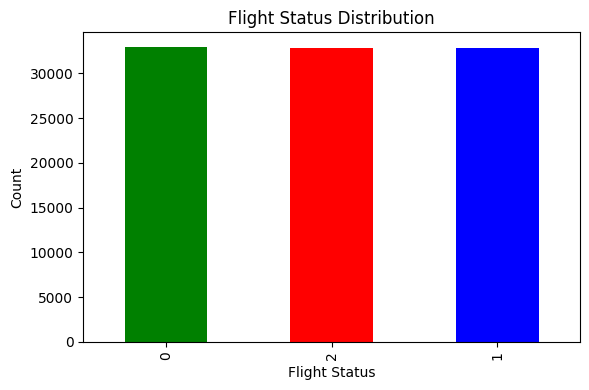

Chart 1 saved!


In [12]:
plt.figure(figsize=(6,4))
df['Flight Status'].value_counts().plot(kind='bar',color=['green','red','blue'])
plt.title('Flight Status Distribution')
plt.xlabel('Flight Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('flight_status_distribution.png')
plt.show()
print("Chart 1 saved!")


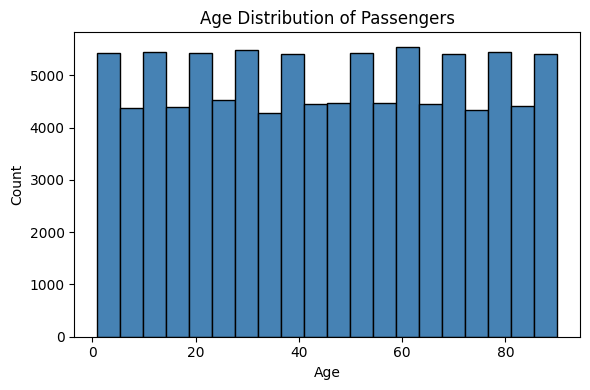

Chart 2 saved!


In [13]:
plt.figure(figsize=(6, 4))
plt.hist(df["Age"], bins=20, color="steelblue", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart2_age.png")
plt.show()
print("Chart 2 saved!")

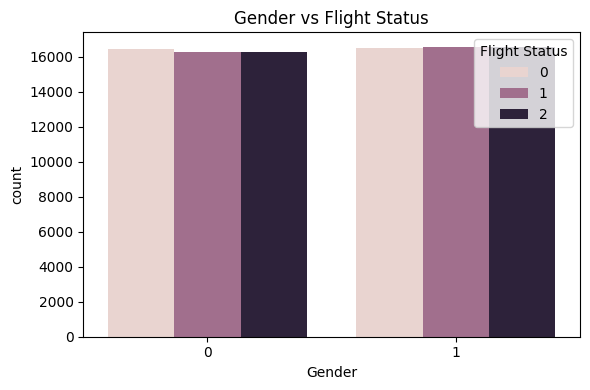

Chart 3 saved!


In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", hue="Flight Status", data=df)
plt.title("Gender vs Flight Status")
plt.tight_layout()
plt.savefig("chart3_gender.png")
plt.show()
print("Chart 3 saved!")

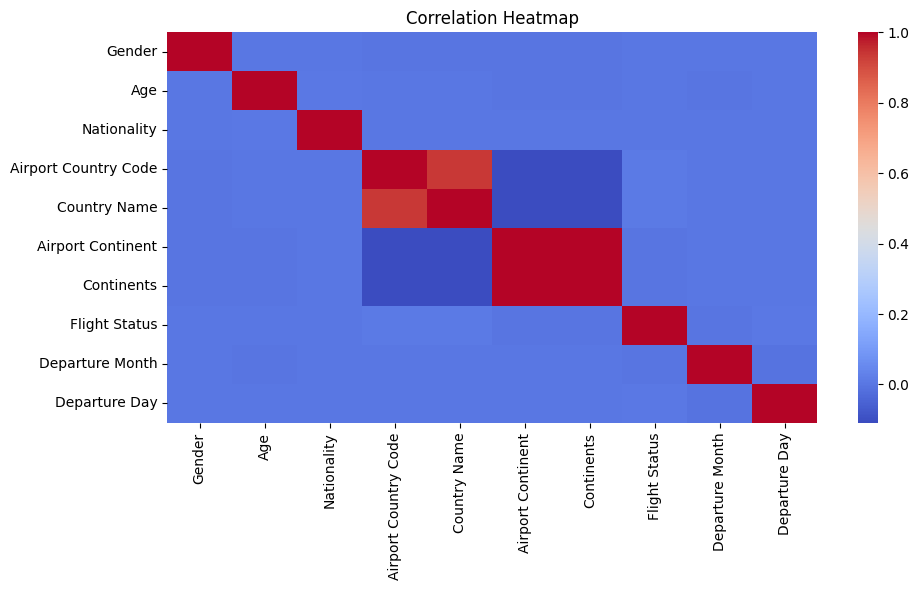

Chart 4 saved!


In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("chart4_heatmap.png")
plt.show()
print("Chart 4 saved!")

DEFINE FEATURES AND TARGET

In [16]:
x=df.drop("Flight Status",axis=1)
y=df["Flight Status"]
print("\nFeatures Shape:",x.shape)
print("Target Shape:",y.shape)


Features Shape: (98619, 9)
Target Shape: (98619,)


SCALE FEATURES

In [17]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print("\nFeatures scaled successfully!")


Features scaled successfully!


TRAIN TEST SPLIT

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)
print("\nTraining samples:",x_train.shape[0])
print("Testing sample:",x_test.shape[0])



Training samples: 78895
Testing sample: 19724


TRAIN 3 MODELS

In [19]:
print("\nTraining Logistic Regression...")
lr=LogisticRegression(max_iter=500)
lr.fit(x_train,y_train)


Training Logistic Regression...


LogisticRegression(max_iter=500)

In [20]:
print("Training Decision Tree...")
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train,y_train)

Training Decision Tree...


DecisionTreeClassifier(max_depth=5, random_state=42)

In [21]:
print("Training Random Forest...")
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
print("\nAll models trained successfully!")

Training Random Forest...

All models trained successfully!


PREDICTIONS

In [22]:
y_pred_lr=lr.predict(x_test)
y_pred_dt=dt.predict(x_test)
y_pred_rf=rf.predict(x_test)

ACCURACY SCORE

In [23]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n========== ACCURACY RESULTS ==========")
print(f"Logistic Regression : {acc_lr * 100:.2f}%")
print(f"Decision Tree       : {acc_dt * 100:.2f}%")
print(f"Random Forest       : {acc_rf * 100:.2f}%")




========== ACCURACY RESULTS ==========
Logistic Regression : 33.33%
Decision Tree       : 33.40%
Random Forest       : 33.62%


CLASSIFICATION REPORT(Best Model)

In [24]:
print("\n====== Random Forest -Detailed Report ======")
print(classification_report(y_test, y_pred_rf))


====== Random Forest -Detailed Report ======
              precision    recall  f1-score   support

           0       0.33      0.34      0.34      6589
           1       0.34      0.34      0.34      6566
           2       0.34      0.33      0.33      6569

    accuracy                           0.34     19724
   macro avg       0.34      0.34      0.34     19724
weighted avg       0.34      0.34      0.34     19724



CONFUSION MATRIX CHART

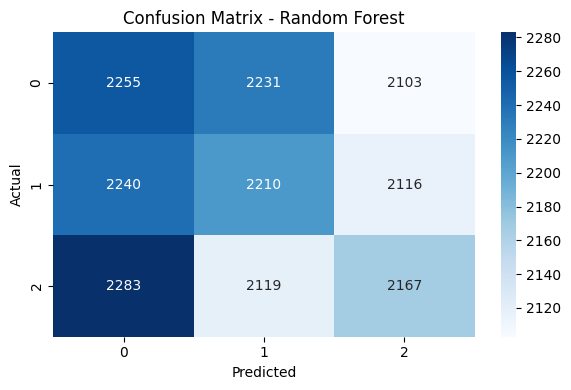

Chart 5 saved!


In [25]:
plt.figure(figsize=(6, 4))
cm=confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("chart5_confusion_matrix.png")
plt.show()
print("Chart 5 saved!")

MODEL CAMPARISION CHART

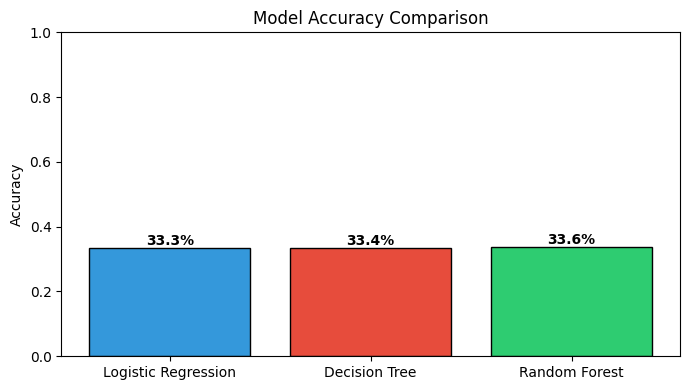

Chart 6 saved!


In [26]:
plt.figure(figsize=(7, 4))
models  = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores  = [acc_lr, acc_dt, acc_rf]
colors  = ["#3498db", "#e74c3c", "#2ecc71"]
plt.bar(models, scores, color=colors, edgecolor="black")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_model_comparison.png")
plt.show()
print("Chart 6 saved!")



FEATURE IMPORTANCE CHART

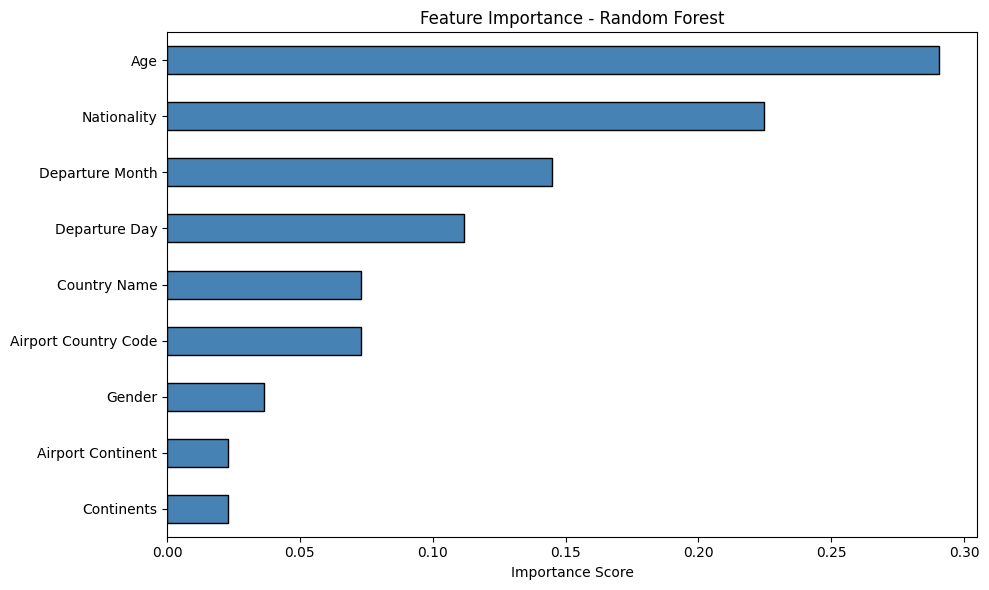

Chart 7 saved!


In [28]:
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(rf.feature_importances_, index=x.columns)
feat_imp.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("chart7_feature_importance.png")
plt.show()
print("Chart 7 saved!")


SAVE THE BEST MODEL

In [29]:
import joblib
joblib.dump(rf, "flight_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nModel saved as flight_model.pkl")


Model saved as flight_model.pkl


PREDICT ON A NEW PASSENGER

In [30]:
print("\n===== SAMPLE PREDICTION =====")

sample = x_test[0].reshape(1, -1)
prediction = rf.predict(sample)

status_map = {0: "Cancelled", 1: "Delayed", 2: "On Time"}
print("Predicted Flight Status:", status_map.get(prediction[0], prediction[0]))



===== SAMPLE PREDICTION =====
Predicted Flight Status: Delayed


In [31]:
print("\n PROJECT COMPLETE!")
print("Charts saved: chart1 to chart7 PNG files")
print("Model saved : flight_model.pkl")


 PROJECT COMPLETE!
Charts saved: chart1 to chart7 PNG files
Model saved : flight_model.pkl
